# Análisis de existencias

En este notebook se revisarán valores nulos y atípicos, y se realizará un análisis univariado de `marca` y `existencias`.

In [1]:
#Importamos las librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#Revisamos los nombres de las hojas disponibles en el archivo
archivo_excel = pd.ExcelFile('Datos_CLV_2026_Tec_v2.xlsx')
archivo_excel.sheet_names

['Diccionario_Datos',
 'Ventas_CLV_2022_2026',
 'Existencias_04_09_2026',
 'Histórico_Compras',
 'Clasificación_Articulos',
 'Salidas_Almacen',
 'Ventas_Negadas_CRM',
 'Negocios_CRM',
 'Metas']

In [3]:
#Cargamos los datos de existencias desde la hoja correspondiente
existencias = pd.read_excel(
    'Datos_CLV_2026_Tec_v2.xlsx',
    sheet_name='Existencias_04_09_2026'
)

#Mostramos los primeros registros
existencias.head()

,articulo_id,nombre_articulo,marca,nombre_almacen,existencias,valor_total_inventario
0,97759,10L MAX BUILD TRAY,Asiga,Almacén General,4,17308.44
1,295121,1L MAX LOW FORCE BUILD TRAY,Asiga,Almacén General,4,3749.14
2,309437,2-2 VALVULA DIRECCIONAL AGUA AIRE,Amann Girrbach,Almacén General,2,6458.84
3,85167,2L MAX BUILD PLASTIC TRAY FOR MAX 3D PRINTER,Asiga,Almacén General,1,1565.35
4,295124,2L ULTRA ULTRAGLOSS BUILD TRAY,Asiga,Almacén General,1,2905.36


In [4]:
#Revisamos tipos de datos y número de registros
existencias.info()

<class 'pandas.DataFrame'>
RangeIndex: 2950 entries, 0 to 2949
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   articulo_id             2950 non-null   int64  
 1   nombre_articulo         2950 non-null   str    
 2   marca                   2950 non-null   str    
 3   nombre_almacen          2950 non-null   str    
 4   existencias             2950 non-null   int64  
 5   valor_total_inventario  2950 non-null   float64
dtypes: float64(1), int64(2), str(3)
memory usage: 273.4 KB


In [5]:
#Identificamos valores nulos por columna
existencias.isnull().sum()

articulo_id               0
nombre_articulo           0
marca                     0
nombre_almacen            0
existencias               0
valor_total_inventario    0
dtype: int64

## Preprocesamiento: valores nulos y valores atípicos

Se conserva una copia del archivo original. Los identificadores no se usan para detectar outliers; para este análisis se revisa la cantidad `existencias`.

In [6]:
#Creamos una copia para conservar los datos originales
existencias_procesadas = existencias.copy()

#Comprobamos los valores nulos en la copia
existencias_procesadas.isnull().sum()

articulo_id               0
nombre_articulo           0
marca                     0
nombre_almacen            0
existencias               0
valor_total_inventario    0
dtype: int64

In [7]:
#Calculamos los límites para detectar valores atípicos con el método IQR
q1_existencias = existencias_procesadas['existencias'].quantile(0.25)
q3_existencias = existencias_procesadas['existencias'].quantile(0.75)
iqr_existencias = q3_existencias - q1_existencias
limite_inferior_existencias = q1_existencias - 1.5 * iqr_existencias
limite_superior_existencias = q3_existencias + 1.5 * iqr_existencias

#Contamos los valores que quedan fuera de los límites
mascara_outliers_existencias = (
    (existencias_procesadas['existencias'] < limite_inferior_existencias) |
    (existencias_procesadas['existencias'] > limite_superior_existencias)
)
mascara_outliers_existencias.sum()

np.int64(408)

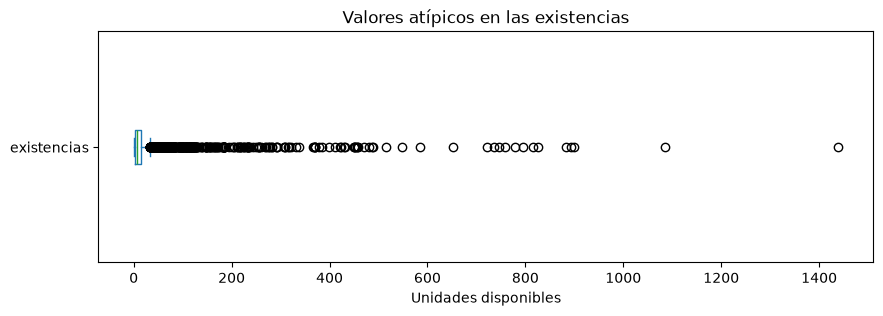

In [8]:
#Visualizamos los valores atípicos antes del tratamiento
existencias_procesadas[['existencias']].plot(kind='box', vert=False, figsize=(10, 3))
plt.title('Valores atípicos en las existencias')
plt.xlabel('Unidades disponibles')
plt.show()

In [9]:
#Reemplazamos los valores atípicos por la mediana de existencias
mediana_existencias = existencias_procesadas['existencias'].median()
existencias_procesadas.loc[mascara_outliers_existencias, 'existencias'] = mediana_existencias

#Verificamos cuántos valores quedan fuera de los límites originales
((existencias_procesadas['existencias'] < limite_inferior_existencias) |
 (existencias_procesadas['existencias'] > limite_superior_existencias)).sum()

np.int64(0)

In [10]:
#Corroboramos que el DataFrame procesado no tenga valores nulos
existencias_procesadas.isnull().sum()

articulo_id               0
nombre_articulo           0
marca                     0
nombre_almacen            0
existencias               0
valor_total_inventario    0
dtype: int64

## Análisis univariado de `marca` y `existencias`

Se presentan tablas de frecuencias con porcentajes y gráficas de barras. Para `existencias`, que es una variable numérica discreta con muchos valores posibles, se grafican y muestran las 10 cantidades más frecuentes.

In [11]:
#Obtenemos la tabla de frecuencias de marca
frecuencia_marca = existencias_procesadas['marca'].value_counts().reset_index()
frecuencia_marca.columns = ['marca', 'frecuencia']
frecuencia_marca['porcentaje'] = frecuencia_marca['frecuencia'] / len(existencias_procesadas) * 100
frecuencia_marca

,marca,frecuencia,porcentaje
0,Vita,1806,61.220339
1,Amann Girrbach,307,10.406780
2,Creation,243,8.237288
3,Aidite,194,6.576271
4,Anax Dent,121,4.101695
5,Huge,88,2.983051
6,Jensen,50,1.694915
7,Scheftner,28,0.949153
8,Phrozen,23,0.779661
9,Asiga,13,0.440678


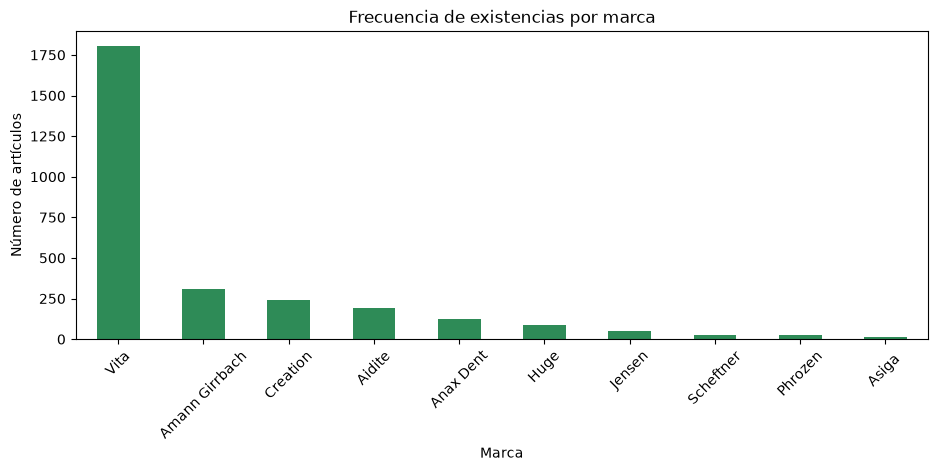

In [12]:
#Graficamos las marcas con mayor frecuencia
frecuencia_marca.head(10).set_index('marca')['frecuencia'].plot(
    kind='bar', figsize=(11, 4), color='seagreen'
)
plt.title('Frecuencia de existencias por marca')
plt.xlabel('Marca')
plt.ylabel('Número de artículos')
plt.xticks(rotation=45)
plt.show()

In [13]:
#Obtenemos la tabla de frecuencias de las cantidades de existencias
frecuencia_existencias = existencias_procesadas['existencias'].value_counts().head(10).reset_index()
frecuencia_existencias.columns = ['existencias', 'frecuencia']
frecuencia_existencias['porcentaje'] = (
    frecuencia_existencias['frecuencia'] / len(existencias_procesadas) * 100
)
frecuencia_existencias

,existencias,frecuencia,porcentaje
0,7,528,17.898305
1,2,290,9.830508
2,1,286,9.694915
3,4,236,8.000000
4,3,230,7.796610
5,5,217,7.355932
6,10,164,5.559322
7,9,137,4.644068
8,6,122,4.135593
9,8,119,4.033898


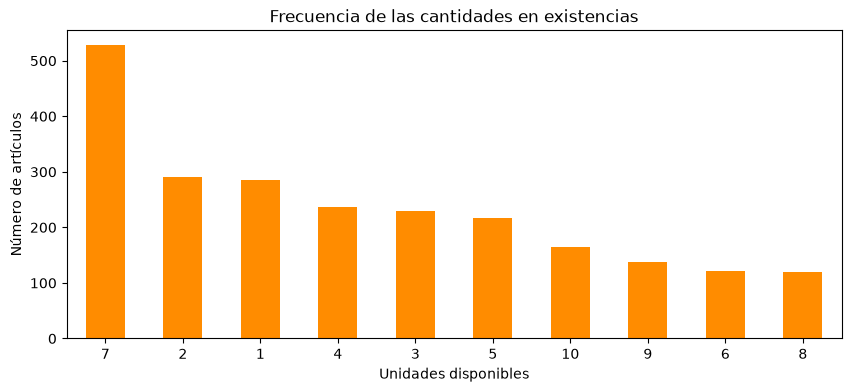

In [14]:
#Graficamos las 10 cantidades de existencias más frecuentes
frecuencia_existencias.set_index('existencias')['frecuencia'].plot(
    kind='bar', figsize=(10, 4), color='darkorange'
)
plt.title('Frecuencia de las cantidades en existencias')
plt.xlabel('Unidades disponibles')
plt.ylabel('Número de artículos')
plt.xticks(rotation=0)
plt.show()

In [15]:
#Mostramos medidas estadísticas básicas de las existencias procesadas
existencias_procesadas['existencias'].describe()

count    2950.000000
mean        7.687458
std         6.243229
min         0.000000
25%         3.000000
50%         7.000000
75%        10.000000
max        33.000000
Name: existencias, dtype: float64

In [16]:
#Guardamos el DataFrame procesado en un archivo Excel
existencias_procesadas.to_excel('Existencias_04_09_2026_procesadas.xlsx', index=False)

#Verificamos el tamaño y los valores nulos del resultado
print('Registros:', len(existencias_procesadas))
print('Valores nulos:', existencias_procesadas.isnull().sum().sum())

Registros: 2950
Valores nulos: 0
